# Import needed packages

In [1]:
import os
import torch
import pandas as pd
import torch
import xarray as xr
import numpy as np
from skimage import io, transform
import random
import matplotlib.pyplot as plt
from torchvision import transforms, utils
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import functions_NN_extremes
import torch.nn as nn                   
import torch.nn.functional as F         
import functions_NN_extremes
from sklearn.metrics import confusion_matrix
import seaborn as sns
import re 
import shap 
from sklearn.metrics import balanced_accuracy_score
import pickle
import functions_improve_CombinedModel
import convnext_functions
import modified_convnext_functions
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors


# Counts HW per year 

Provides a plot with the sum of yearly extreme counts. Includes a computation of the mean number of counts in the reference period used to compute climatologies, percentiles, and drought indices (SPEI, SPI)

Doing site: cordoba


ERROR 1: PROJ: proj_create_from_database: Open of /srv/conda/envs/notebook/share/proj failed


Mean counts 1950-2000 for cordoba is : 5.354166666666667
Doing site: lyon
Mean counts 1950-2000 for lyon is : 7.229166666666667
Doing site: hannover
Mean counts 1950-2000 for hannover is : 3.4166666666666665
Doing site: stockholm
Mean counts 1950-2000 for stockholm is : 4.239130434782608
Doing site: belgrado
Mean counts 1950-2000 for belgrado is : 4.520833333333333
Doing site: marrakech
Mean counts 1950-2000 for marrakech is : 4.0625


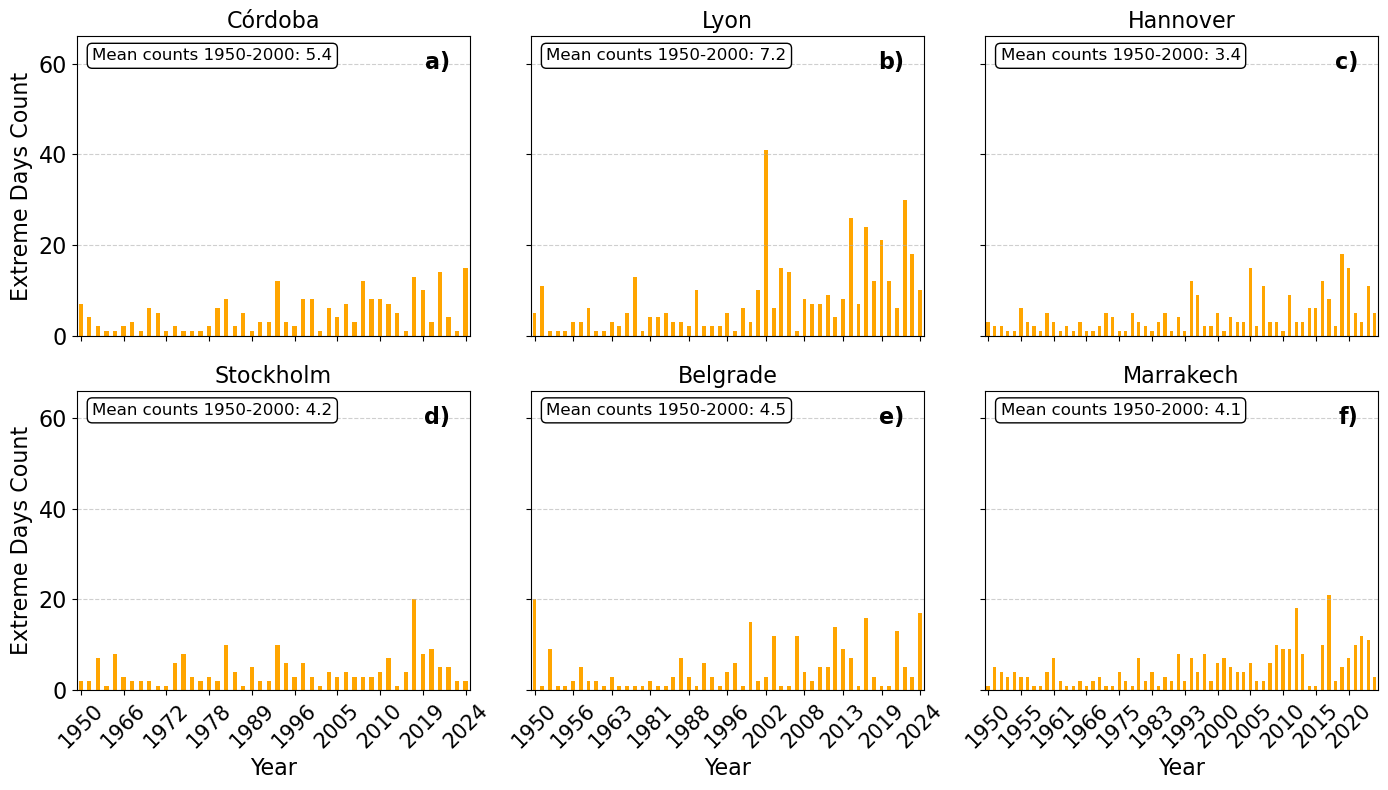

In [2]:

# List of site names (file identifiers) and their display titles for plots
sites = ['cordoba', 'lyon', 'hannover', 'stockholm', 'belgrado', 'marrakech']
sites_title = ['Córdoba', 'Lyon', 'Hannover', 'Stockholm', 'Belgrade', 'Marrakech']

# Create subplots with shared axes - 2 rows, 3 columns
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey='row', sharex='col')
# Flatten the 2D array of axes to 1D for easier iteration
axes = axes.flatten()

# Create date range from 1950 to 2024 with daily frequency
date_range = pd.date_range(start='1950-01-01', end='2024-12-31', freq='D')
# Filter dates to only include June, July, August months, excluding July 31, 2024
filtered_dates = np.array([
    d for d in date_range 
    if d.month in [6, 7, 8] and not (d.year == 2024 and d.month == 7 and d.day == 31)
])


# Loop through each site to create individual plots
for i, site in enumerate(sites): 
    print(f"Doing site: {site}")

    # Load dataset for the current site using custom function
    dataset = functions_NN_extremes.ERA5LandDataset_extremes_location_swvl_averaged(file_path=f"/gpfs/scratch/bsc32/bsc167965/tfm_data/era5_land/lagged_anomalies_and_event_detection/98p_{site}_lagged_standarized_anomalies_and_extreme_detection.nc", start_date="1950-01-03", end_date="2024-12-31", months=[6,7,8])
    
    
    # Extract true labels from the dataset (extreme event indicators)
    y_true = dataset.labels
    
    # Create DataFrame with dates and corresponding labels
    df = pd.DataFrame({
        'date': filtered_dates,
        'label': y_true
    })
    # Extract year from date for grouping
    df['year'] = pd.DatetimeIndex(df['date']).year
    # Count number of extreme days (label = 1) per year
    counts = df[df['label'] == 1].groupby('year').size()
    # Ensure proper grouping (redundant but safe)
    counts = counts.groupby(counts.index).sum()  
    # Sort by year index
    counts = counts.sort_index()
    # Convert index to integer years
    counts.index = counts.index.astype(int)
    # Calculate mean extreme days count for baseline period (1950-2000)
    mean_counts = np.mean(counts[:48])
    print(f"Mean counts 1950-2000 for {site} is : {mean_counts}")
    
    # Get the current subplot axis
    ax = axes[i]
    # Clear any existing content
    ax.clear()
    # Create bar plot of yearly extreme counts
    counts.plot(kind='bar', ax=ax, color='orange')
    # Set title using formatted site name
    ax.set_title(sites_title[i],fontsize=16)
    # Set x-axis label
    ax.set_xlabel('Year', fontsize=16)

    # Add subplot label (a), b), c), etc.) in top-right corner
    ax.text(0.95, 0.95, f'{chr(97+i)})',  # 97 is ASCII for 'a'
            transform=ax.transAxes,
            fontsize=16,
            fontweight='bold',
            va='top',
            ha='right')
    
    # Only set ylabel for leftmost plots (first column)
    if i % 3 == 0:
        ax.set_ylabel('Extreme Days Count', fontsize=16)
    
    # Set x-axis ticks to show every 5 years
    ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
    # Set x-axis tick label font size
    ax.tick_params(axis='x', labelsize=15)
    # Rotate x-axis labels for better readability
    for tick in ax.get_xticklabels():
        tick.set_rotation(45)
    
    # Set y-axis tick label font size
    ax.tick_params(axis='y', labelsize=16)
    # Add horizontal grid lines for easier reading
    ax.grid(axis='y', linestyle='--', alpha=0.6)

    # Add text box showing mean counts for baseline period
    ax.text(0.04, 0.96,
               f"Mean counts 1950-2000: {mean_counts:.1f}",
               transform=ax.transAxes,
               fontsize=12,
               verticalalignment='top',
               bbox=dict(boxstyle="round", facecolor="white"))

    # Set consistent y-axis limits across all plots
    ax.set_ylim(0,66)

# Adjust layout to prevent overlapping elements
plt.tight_layout()
# Save the figure as PDF
plt.savefig("/home/bsc/bsc167965/TFM/input_data/arnau-tfm/plots/98p_yearly_counts_extremes_locations.pdf")
# Display the plot
plt.show()

# Count per year comparison

Same plot as in the previous block but including data from E-OBS gridded dataset and ERA5 reanalysis to compare the number of yearly extremes. 

Doing site: cordoba
Doing site: lyon
Doing site: hannover
Doing site: stockholm
Doing site: belgrado
Doing site: marrakech


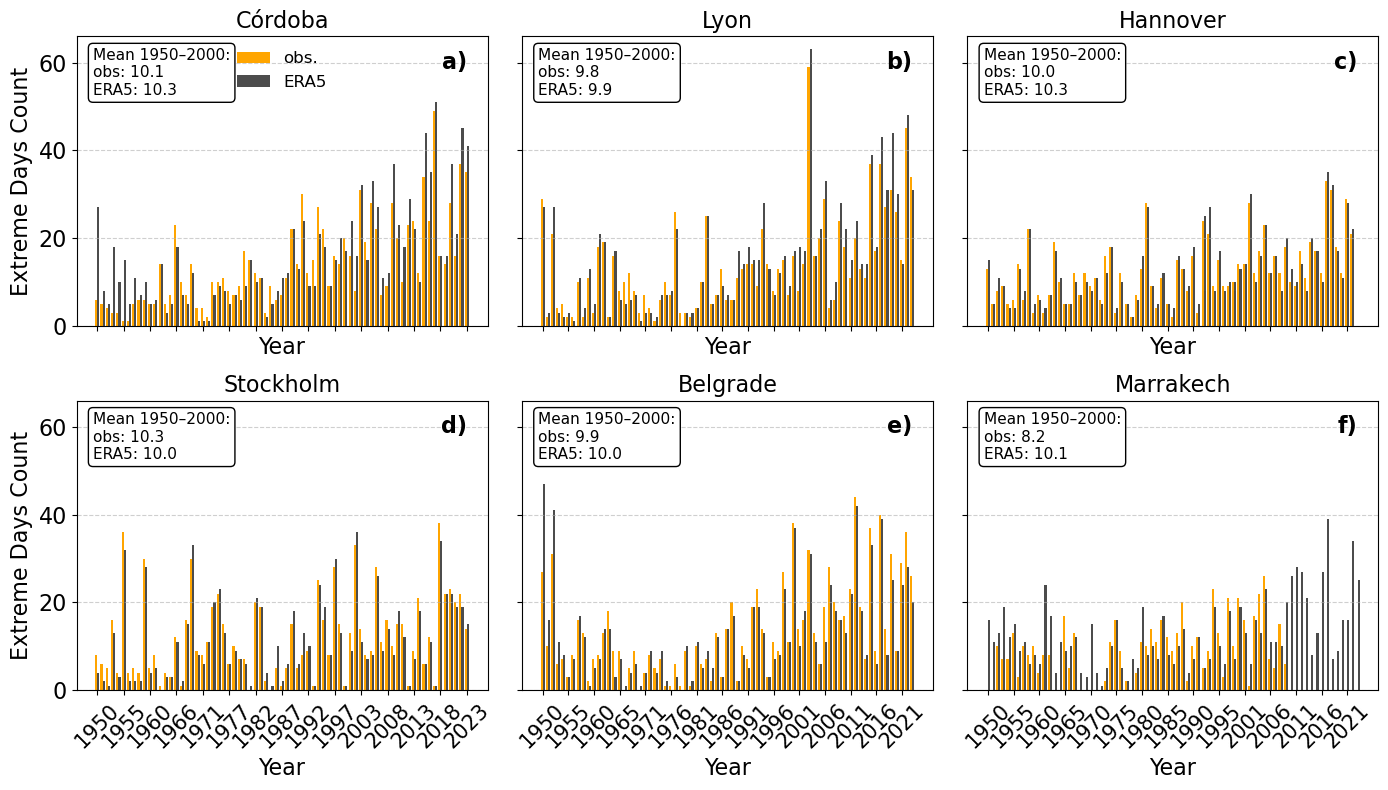

In [11]:

# List of site names (file identifiers) and their display titles for plots
sites = ['cordoba', 'lyon', 'hannover', 'stockholm', 'belgrado', 'marrakech']
sites_title = ['Córdoba', 'Lyon', 'Hannover', 'Stockholm', 'Belgrade', 'Marrakech']

# Create subplots with shared axes - 2 rows, 3 columns
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey='row', sharex='col')
# Flatten the 2D array of axes to 1D for easier iteration
axes = axes.flatten()

# Create date range from 1950 to 2023 with daily frequency
date_range = pd.date_range(start='1950-01-01', end='2023-12-31', freq='D')

filtered_dates = np.array([
    d for d in date_range 
    if d.month in [6, 7, 8] and not (d.year == 2024 and d.month == 7 and d.day == 31)
])

# Set width for grouped bars
bar_width = 0.4

# Loop through each site to create individual comparison plots
for i, site in enumerate(sites): 
    print(f"Doing site: {site}")

    # First dataset (observation-based)
    dataset = functions_NN_extremes.ERA5LandDataset_extremes_location_swvl_averaged(
        file_path=f"/file/path/",
        start_date="1950-01-03", end_date="2023-12-31", months=[6,7,8])
    
    # Extract true labels from observation dataset
    y_true = dataset.labels
    # Create DataFrame with dates and observation labels
    df = pd.DataFrame({'date': filtered_dates, 'label': y_true})
    # Extract year from date for grouping
    df['year'] = df['date'].dt.year
    # Count number of extreme days (label = 1) per year for observations
    counts_obs = df[df['label'] == 1].groupby('year').size()

    # Second dataset 
    dataset_alt = functions_NN_extremes.ERA5LandDataset_extremes_location_swvl_averaged(
        file_path= "file/path/",
        start_date="1950-01-03", end_date="2023-12-31", months=[6,7,8])
    
    # Extract true labels from ERA5 dataset
    y_true_alt = dataset_alt.labels
    # Create DataFrame with dates and ERA5 labels
    df_alt = pd.DataFrame({'date': filtered_dates, 'label': y_true_alt})
    # Extract year from date for grouping
    df_alt['year'] = df_alt['date'].dt.year
    # Count number of extreme days (label = 1) per year for ERA5
    counts_alt = df_alt[df_alt['label'] == 1].groupby('year').size()

    # Align both datasets to the same set of years (union of all years)
    all_years = sorted(set(counts_obs.index).union(set(counts_alt.index)))
    # Reindex both series to include all years, filling missing years with 0
    counts_obs = counts_obs.reindex(all_years, fill_value=0)
    counts_alt = counts_alt.reindex(all_years, fill_value=0)

    # Calculate mean extreme days count for baseline period (1950-2000) for both datasets
    mean_counts_obs = np.mean(counts_obs.loc[1950:2000])
    mean_counts_alt = np.mean(counts_alt.loc[1950:2000])

    # Plot the comparison bars
    ax = axes[i]
    ax.clear()

    # Create x positions for grouped bars
    x = np.arange(len(all_years))
    # Plot observation counts as orange bars (left side of each group)
    ax.bar(x - bar_width/2, counts_obs.values, width=bar_width, color='orange', label='obs.')
    # Plot ERA5 counts as black bars (right side of each group)
    ax.bar(x + bar_width/2, counts_alt.values, width=bar_width, color='black', alpha=0.7, label='ERA5')

    # Set plot title and labels
    ax.set_title(sites_title[i], fontsize=16)
    ax.set_xlabel('Year', fontsize=16)
    # Set x-axis ticks to show every 5 years
    ax.set_xticks(x[::5])
    # Set x-axis tick labels with rotation for readability
    ax.set_xticklabels([str(year) for year in all_years][::5], rotation=45, fontsize=15)

    # Only set ylabel for leftmost plots (first column)
    if i % 3 == 0:
        ax.set_ylabel('Extreme Days Count', fontsize=16)
    
    # Set y-axis tick label font size
    ax.tick_params(axis='y', labelsize=16)
    # Add horizontal grid lines for easier reading
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    # Set consistent y-axis limits across all plots
    ax.set_ylim(0, 66)

    # Add subplot label (a), b), c), etc.) in top-right corner
    ax.text(0.95, 0.95, f'{chr(97+i)})',
            transform=ax.transAxes,
            fontsize=16,
            fontweight='bold',
            va='top',
            ha='right')
    
    # Add text box showing mean counts for both datasets during baseline period
    ax.text(0.04, 0.96,
            f"Mean 1950–2000:\nobs: {mean_counts_obs:.1f}\nERA5: {mean_counts_alt:.1f}",
            transform=ax.transAxes,
            fontsize=11,
            verticalalignment='top',
            bbox=dict(boxstyle="round", facecolor="white"))

# Add legend to the first subplot showing the color coding for both datasets
axes[0].legend(fontsize=12, loc='upper center', frameon=False)

# Adjust layout to prevent overlapping elements
plt.tight_layout()
# Display the plot
plt.show()

# Mean Absolute SHAP values

doing site: cordoba
Finished site cordoba
doing site: lyon
Finished site lyon
doing site: hannover
Finished site hannover
doing site: stockholm
Finished site stockholm
doing site: belgrado
Finished site belgrado
doing site: marrakech
Finished site marrakech


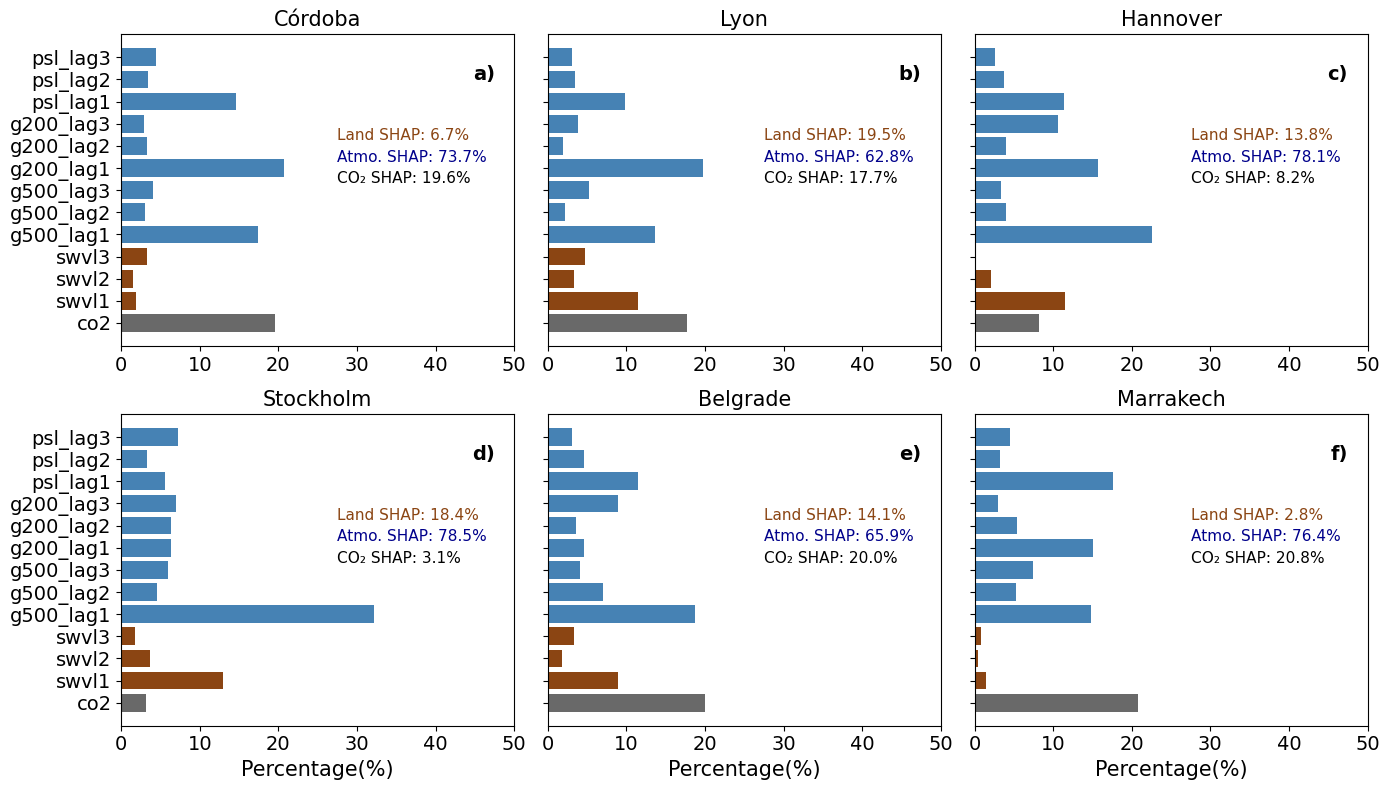

In [10]:
# Function to draw colored text blocks for displaying SHAP percentage summaries
def draw_colored_text_block(ax, x, y, items):
    for i, (name, value, color) in enumerate(items):
        ax.text(x, y - i*0.07, f"{name}: {value:.1f}%", transform=ax.transAxes,
                fontsize=11, color=color, verticalalignment='top')

# Define colors for different feature categories
atmo_color = 'steelblue'  # Color for atmospheric circulation features
land_color = 'saddlebrown'    # Color for land/soil moisture features
co2_color = 'dimgray'    # Color for CO2 features

# List of site names and their display titles
sites = ['cordoba','lyon','hannover' ,'stockholm','belgrado','marrakech']
sites_title = ['Córdoba', 'Lyon', 'Hannover', 'Stockholm', 'Belgrade' ,'Marrakech']

# -----------------------------------------

# Configuration dictionaries for data loaders

# Training data loader configuration
_DATALOADERS_CONF = dict(
        batch_size= 32,
        drop_last= False,
        shuffle = True,
    )
    
# Test data loader configuration (no shuffling for evaluation)
_DATALOADERS_TEST_CONF = dict(
        batch_size= 32,
        drop_last= False,
        shuffle = False,
    ) 
    
# Hyperparameters for model training
HYPMS = dict(
    epochs= 75,
    lr= 1e-4,
    w_decay= 0.01,
)

# File paths for ERA5 atmospheric data variables
file_g500 = "/path/to/g500/data/file.nc"
file_g200 = "/path/to/g500/data/file.nc"
file_psl = "/path/to/g500/data/file.nc"

# File path for CO2 data
file_CO2 = "/home/bsc/bsc167965/TFM/ML/data_files/daily_co2_JJA.nc"

# Training features configuration
number_lags = 3  # Number of lag days to include as features

# Combined Dataset and Dataloader 
batch_size = _DATALOADERS_CONF['batch_size'] # batch size for dataloaders both datasets

# Create subplots for SHAP bar plots
fig_bar,axes_bar = plt.subplots(2,3,figsize=(14,8), sharex='col', sharey='row')
axes_bar = axes_bar.flatten()

count_plot = 0  # Counter for tracking subplot position

# Loop through each site to process and plot SHAP values
for s,site in enumerate(sites): 
    print(f"doing site: {site}")
    
    start_date = "1950-01-01"
    
    file_CO2 = "/path/to/CO2/file/"
    
    # Configuration dictionaries for datasets
    _ERA5LAND_COMPLETE_DATASET_CONF = dict(
    start_date= start_date,
    end_date= "2024-12-31",
    months = [6,7,8]         # Summer months (JJA)
        )

    _ERA5_COMPLETE_DATASET_CONF = dict(
    start_date= start_date,
    end_date= "2024-12-31",
    start_lag = 1,
    lags_era5 = 3,
    months = [6,7,8],
            )

    # Create training and test datasets with CO2 data
    train_dataset = functions_NN_extremes.ERA5LandDataset_extremes_location_swvl_averaged_including_CO2(file_path=f"/gpfs/scratch/bsc32/bsc167965/tfm_data/era5_land/lagged_anomalies_and_event_detection/std_changed_{site}_lagged_standarized_anomalies_and_95p_extreme_detection.nc", file_CO2=file_CO2 ,start_date=start_date, end_date="2013-12-31", months=[6,7,8])
    test_dataset = functions_NN_extremes.ERA5LandDataset_extremes_location_swvl_averaged_including_CO2(file_path=f"/gpfs/scratch/bsc32/bsc167965/tfm_data/era5_land/lagged_anomalies_and_event_detection/std_changed_{site}_lagged_standarized_anomalies_and_95p_extreme_detection.nc", file_CO2=file_CO2 ,start_date="2014-01-01", end_date="2023-12-31", months=[6,7,8])
        
    # Create ERA5 atmospheric feature datasets
    train_features_era5 = functions_NN_extremes.ERA5Dataset_extremes(file_g500,file_g200,file_psl, start_date=start_date, end_date='2013-12-31',months=[6,7,8],start_lag=1,lags_era5=number_lags) # shape: features, time, lat, lon 
    test_features_era5 = functions_NN_extremes.ERA5Dataset_extremes(file_g500,file_g200,file_psl, start_date='2014-01-01', end_date='2023-12-31', months=[6,7,8],start_lag=1,lags_era5=number_lags)

    # Combine land and atmospheric datasets
    combined_train_dataset  = functions_NN_extremes.CombinedDataset(train_dataset,train_features_era5)
    combined_test_dataset = functions_NN_extremes.CombinedDataset(test_dataset,test_features_era5)
          
    # Set device for GPU/CPU computation
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Prepare explainer data for SHAP analysis
    explainer_indices = np.arange(0,len(combined_test_dataset),1)
    
    explain_nn = []
    explain_cnn = []
    
    # Extract test data for SHAP explanation
    for idx in explainer_indices:
        nn_input, cnn_input, labels = combined_test_dataset[idx]  # Adjust based on your dataset structure
        explain_nn.append(nn_input)
        explain_cnn.append(cnn_input)
    
    explain_nn = torch.stack(explain_nn,dim=0).to(device)
    explain_cnn = torch.stack(explain_cnn,dim=0).to(device)
    
    explain_data = [explain_nn, explain_cnn]
    
    # Load pre-computed SHAP values and model results
    main_path = '/your/path/to/stats/results/'
    with open(os.path.join(main_path, f'95p_results_data_{site}.pkl'), 'rb') as f:
        dict_results = pickle.load(f)

    main_path = '/your/path/to/shap/results'
    with open(os.path.join(main_path, f'95p_SHAP_results_{site}.pkl'), 'rb') as f:
        loaded_shap_dict = pickle.load(f)

    # Extract model outputs
    out_probabilities = dict_results['out_probs_sites']   
    y_true,y_pred = dict_results['y_true_pred_pairs']
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
        
    # Filter predictions based on confidence thresholds
    mask = np.zeros_like(out_probabilities, dtype=bool)
    
    for i in range(out_probabilities.shape[1]):
        threshold = np.percentile(out_probabilities[:, i], 100 - 25)  # Top 25% confident predictions
        mask[:, i] = out_probabilities[:, i] >= threshold
    
    mask_def = mask[:,0] | mask[:,1] #True if either class 0 or 1 correspond to the top % confidence 
    mask_def_extreme = mask_def & (y_pred == 1)  # Filter for high-confidence extreme events

    # Load and filter SHAP values
    shap_values_nn_raw = loaded_shap_dict['nn_mean']
    shap_values_cnn_raw = loaded_shap_dict['cnn_mean']

    # Filter SHAP values using the confidence mask
    shap_values_nn_filtered = shap_values_nn_raw[mask_def_extreme]
    shap_values_cnn_filtered = shap_values_cnn_raw[mask_def_extreme]

    # Get feature names and prepare for visualization
    explain_nn_np = explain_nn.cpu().numpy()
    
    nn_feature_names = test_dataset.all_features
    cnn_feature_names = test_features_era5.all_features
    all_names = nn_feature_names + cnn_feature_names
    
    # Clean feature names for display
    cleaned_names = [
    name.replace("_anomalies", "").replace("lagged_era5", "")
    if "lagged_era5" in name else name.replace("_anomalies", "")
    for name in all_names
    ]

    # Assign colors to features based on their category
    color_mapping = {}
    circulation_features = ['g500', 'g200', 'psl']  # Atmospheric circulation
    land_features = ['swvl1', 'swvl2', 'swvl3']     # Soil moisture
    co2_feature = ['co2']  # CO2 feature
    
    for name in cleaned_names:
        lname = name.lower()
        if any(circ in lname for circ in circulation_features):
            color_mapping[name] = atmo_color
        elif any(swvl in lname for swvl in land_features):
            color_mapping[name] = land_color
        elif 'co2' in lname:
            color_mapping[name] = co2_color

    # Create SHAP Explanation object for NN features
    expl_nn = shap.Explanation(
        values=shap_values_nn_filtered,
        data=explain_nn.cpu().numpy()[mask_def_extreme],
        feature_names=nn_feature_names
    )

    # Process CNN SHAP values by summing over spatial dimensions
    shap_values_cnn_sum_spatial = np.sum(shap_values_cnn_filtered,axis=(2,3))

    # Combine NN and CNN SHAP values
    all_shap_values = np.concatenate([shap_values_nn_filtered,shap_values_cnn_sum_spatial],axis=1)

    # Calculate absolute SHAP values for importance ranking
    abs_shap = np.abs(all_shap_values)
    mean_abs_shap = np.mean(np.abs(all_shap_values), axis=0)  # Mean absolute SHAP per feature
    total_mean_shap = np.sum(mean_abs_shap[:],axis=0)  # Total SHAP importance

    # Calculate percentage contributions by feature category
    land_SHAP = np.sum(mean_abs_shap[1:4]) / total_mean_shap * 100      # Soil moisture features
    atmosphere_SHAP = np.sum(mean_abs_shap[4:]) / total_mean_shap * 100  # Atmospheric features
    co2_SHAP = np.sum(mean_abs_shap[:1]) / total_mean_shap * 100         # CO2 feature

    # Create horizontal bar plot of SHAP importance percentages
    axes_bar[count_plot].set_xticks(np.arange(0, 55, 10))
    bar_colors = [color_mapping[name] for name in cleaned_names]  # Get colors for each feature
    axes_bar[count_plot].barh(cleaned_names, mean_abs_shap / total_mean_shap * 100, color=bar_colors)   
    axes_bar[count_plot].set_xlim(0,50)  # Set x-axis limit to 50%
    axes_bar[count_plot].set_title(f"{sites_title[s]}",fontsize=15)
    
    # Add subplot label (a), b), etc.)
    axes_bar[count_plot].text(0.95, 0.9, f'{chr(97+count_plot)})',  # 97 is ASCII for 'a'
                            transform=axes_bar[count_plot].transAxes,
                            fontsize=14,
                            fontweight='bold',
                            va='top',
                            ha='right')
    
    # Create summary items for category percentages
    summary_items = [
        ("Land SHAP", land_SHAP, 'saddlebrown'),
        ("Atmo. SHAP", atmosphere_SHAP, 'darkblue'),
        ("CO₂ SHAP", co2_SHAP, 'black')
    ]

    # Draw colored text block with category summaries
    draw_colored_text_block(axes_bar[count_plot], 0.55, 0.70, summary_items)

    # Format axes
    axes_bar[count_plot].tick_params(axis='y', labelsize=14) 
    axes_bar[count_plot].tick_params(axis='x', labelsize=14) 
    axes_bar[count_plot].xaxis.set_ticks_position('bottom')

    count_plot += 1
    print(f"Finished site {site}")

# Add x-axis labels to bottom row subplots
for m in range(3,6):
    axes_bar[m].set_xlabel("Percentage(%)",fontsize=15)

# Adjust layout and display
fig_bar.tight_layout()

## Beeswarm SHAP plot using Matplotlib

doing site: cordoba
doing site: lyon
doing site: hannover
doing site: stockholm
doing site: belgrado


/scratch/tmp/23481838/ipykernel_390718/873686652.py:216: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(right=0.85)


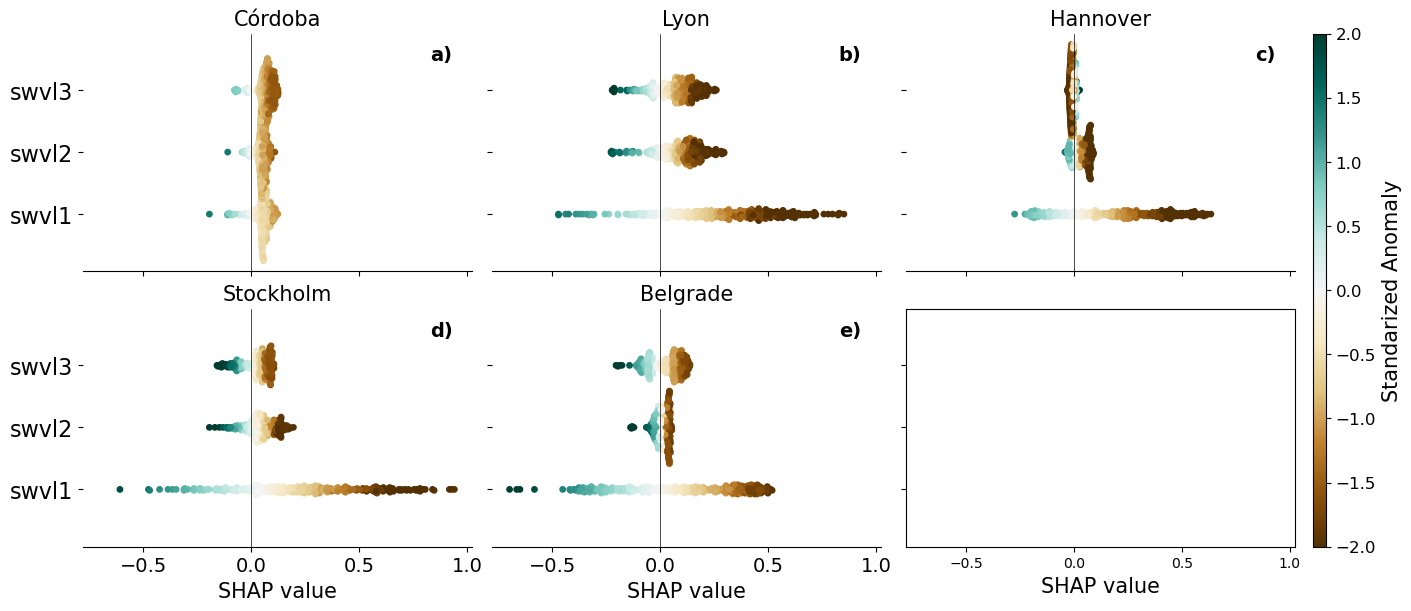

In [7]:
import matplotlib.pyplot as plt
import shap
import pickle
import numpy as np
from io import BytesIO
from PIL import Image
from matplotlib import cm
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import rankdata
import shap

# File path for CO2 data
file_CO2 = "/home/bsc/bsc167965/TFM/ML/data_files/daily_co2_JJA.nc"

# Get SHAP's default red-blue color scheme and create a colormap from it
shap_colors = shap.plots.colors.red_blue
shap_color_func = shap.plots.colors.red_blue  # this is a function
color_vals = np.linspace(0, 1, 256)           # 256 gradient steps
rgb_colors = [shap_color_func(v) for v in color_vals]  # sample into RGB

# Create custom colormap from SHAP's red-blue colors
shap_colormap = LinearSegmentedColormap.from_list(
    "shap_red_blue", 
    rgb_colors
)

# Create custom brown-to-green colormap for soil moisture visualization
soil_moisture_colors = LinearSegmentedColormap.from_list(
    "soil_moisture_brown_green",
    ["saddlebrown", "wheat", "yellowgreen", "forestgreen"],
    N=256
)

def beeswarm_y(vals, gap=0.01):
    """
    Generates SHAP-like vertical jittering to separate overlapping SHAP values.
    Now with centered bidirectional offsets (up/down) to avoid stacking only above.
    """
    from collections import defaultdict

    sorted_idx = np.argsort(vals)  # Sort values for efficient placement
    sorted_vals = vals[sorted_idx]

    y_positions = np.zeros(len(vals))
    layers = defaultdict(list)  # Dictionary to track values at each vertical layer

    # Place points in layers to avoid overlap
    for idx, val in zip(sorted_idx, sorted_vals):
        for layer_num in range(100):  # Try up to 100 layers
            offset = (layer_num + 1) // 2 * (-1)**layer_num  # Alternate up/down offsets
            layer = layers[offset]
            if all(abs(val - v) > gap for v in layer):  # Check if point fits in this layer
                layer.append(val)
                y_positions[idx] = offset
                break

    # Scale spacing for aesthetics
    y_positions = y_positions * 0.15
    return y_positions

def custom_summary_plot(ax, shap_values, features, feature_names, cmap=cm.coolwarm, dot_size=15,vmin=-2,vmax=2):
    """
    Custom SHAP summary plot function that creates beeswarm-style visualization
    """
    num_features = shap_values.shape[1]

    # Plot each feature's SHAP values
    for i in range(num_features):
        vals = shap_values[:, i]  # SHAP values for current feature
        color_vals = features[:, i]  # Feature values for coloring
        y_offsets = beeswarm_y(vals) * 0.1  # scale for vertical spread

        # Create scatter plot with colored points
        ax.scatter(vals, i + y_offsets,
                   c=color_vals, cmap=cmap,
                   s=dot_size, alpha=1, edgecolors=None, vmin=-2, vmax=2)

    # Set y-axis labels as feature names
    ax.set_yticks(range(num_features))
    ax.set_yticklabels(feature_names, fontsize=16)
    ax.tick_params(axis='x', labelsize=14)

# Create subplots for multiple sites
fig, axs = plt.subplots(2, 3, figsize=(14, 6), sharex=True, sharey=True,constrained_layout=True) # sharex and sharey
axs = axs.flatten()

# Site names for titles
sites_title = ['Córdoba', 'Lyon', 'Hannover', 'Stockholm', 'Belgrade', 'Marrakech']
sites = ['cordoba','lyon','hannover' ,'stockholm', 'belgrado']

# Initialize variables to track data range for consistent coloring
v_min = 0 
v_max = 0

# Loop through each site to create SHAP summary plots
for count_plot, site in enumerate(sites):

    print(f"doing site: {site}")

    start_date = "1950-01-01"
    
    file_CO2 = "/home/bsc/bsc167965/TFM/ML/data_files/daily_co2_JJA.nc"
    # Configuration dictionaries for datasets
    _ERA5LAND_COMPLETE_DATASET_CONF = dict(
    start_date= start_date,
    end_date= "2023-12-31",
    months = [6,7,8]         # Summer months (JJA)
        )

    _ERA5_COMPLETE_DATASET_CONF = dict(
    start_date= start_date,
    end_date= "2023-12-31",
    start_lag = 1,
    lags_era5 = 3,
    months = [6,7,8],
            )

    file_local_scale = f"/gpfs/scratch/bsc32/bsc167965/tfm_data/era5_land/obs_lagged_anomalies_and_event_detection/obs_{site}_lagged_standarized_anomalies_and_extreme_detection.nc"

    # Create training and test datasets with observational data
    train_dataset = functions_NN_extremes.ERA5LandDataset_extremes_location_swvl_averaged_including_CO2(file_path=file_local_scale, file_CO2=file_CO2 ,start_date=start_date, end_date="2013-12-31", months=[6,7,8])
    test_dataset = functions_NN_extremes.ERA5LandDataset_extremes_location_swvl_averaged_including_CO2(file_path=file_local_scale, file_CO2=file_CO2 ,start_date="2014-01-01", end_date="2023-12-31", months=[6,7,8])
        
    # Create ERA5 atmospheric feature datasets
    train_features_era5 = functions_NN_extremes.ERA5Dataset_extremes(file_g500,file_g200,file_psl, start_date=start_date, end_date='2013-12-31',months=[6,7,8],start_lag=1,lags_era5=number_lags) # shape: features, time, lat, lon 
    test_features_era5 = functions_NN_extremes.ERA5Dataset_extremes(file_g500,file_g200,file_psl, start_date='2014-01-01', end_date='2023-12-31', months=[6,7,8],start_lag=1,lags_era5=number_lags)

    # Combine land and atmospheric datasets
    combined_train_dataset  = functions_NN_extremes.CombinedDataset(train_dataset,train_features_era5)
    combined_test_dataset = functions_NN_extremes.CombinedDataset(test_dataset,test_features_era5)

    # Set device for GPU/CPU computation
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Prepare explainer data for SHAP analysis
    explainer_indices = np.arange(0,len(combined_test_dataset),1)
    
    explain_nn = []
    explain_cnn = []
    
    # Extract test data for SHAP explanation
    for idx in explainer_indices:
        nn_input, cnn_input, labels = combined_test_dataset[idx] # Adjust based on your dataset structure
        explain_nn.append(nn_input)
        explain_cnn.append(cnn_input)
    
    explain_nn = torch.stack(explain_nn,dim=0).to(device)
    explain_cnn = torch.stack(explain_cnn,dim=0).to(device)
    
    explain_data = [explain_nn, explain_cnn]
    
    # Load pre-computed SHAP values and model results
    with open(f'/path/SHAP/results/file.pkl', 'rb') as f:
        loaded_shap_dict = pickle.load(f)
    main_path = '/path/evaluation/results/'
    with open(os.path.join(main_path, f'file.pkl'), 'rb') as f:
        dict_results = pickle.load(f)
    
    # Extract model outputs and predictions
    out_probabilities = dict_results['out_probs_sites']
    y_true,y_pred = dict_results['y_true_pred_pairs']
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Filter predictions based on confidence thresholds
    mask = np.zeros_like(out_probabilities, dtype=bool)
    for i in range(out_probabilities.shape[1]):
        threshold = np.percentile(out_probabilities[:, i], 0.75)  # Top 25% confident predictions
        mask[:, i] = out_probabilities[:, i] >= threshold
    mask_def = mask[:, 0] | mask[:, 1]  # Union of confident predictions for both classes
    mask_def_extreme = mask_def & (y_pred == 1)  # Filter for high-confidence extreme events

    # Load and filter SHAP values
    shap_values_nn_raw = loaded_shap_dict['nn_mean']
    shap_values_nn_filtered = shap_values_nn_raw[mask_def_extreme]
    input_data = explain_nn.cpu().numpy()[mask_def_extreme]  # Corresponding input features
    
    # Get feature names and clean them for display
    nn_feature_names = train_dataset.all_features

    cleaned_names = [
        name.replace("_anomalies", "").replace("lagged_era5", "")
        if "lagged_era5" in name else name.replace("_anomalies", "")
        for name in nn_feature_names ]
    
    # Create SHAP Explanation object for soil moisture features (indices 1:4)
    expl_nn = shap.Explanation(
        values=shap_values_nn_filtered[:,1:4],
        data=input_data[:,1:4],
        feature_names=cleaned_names[1:4])
    
    # Create custom summary plot for current site
    ax = axs[count_plot]
    # Plot only soil moisture features (indices 1-3) using BrBG colormap
    custom_summary_plot(ax, shap_values_nn_filtered[:,1:4], input_data[:,1:4], cleaned_names[1:4],cmap="BrBG", vmin=-2, vmax=2)
    ax.set_title(sites_title[count_plot], fontsize=15)
    ax.axvline(x=0, color='black', linewidth=0.5, linestyle='-')  # Vertical line at SHAP=0
    
    # Add subplot label (a), b), etc.)
    ax.text(0.95, 0.95, f'{chr(97+count_plot)})',  # 97 is ASCII for 'a'
                            transform=ax.transAxes,
                            fontsize=14,
                            fontweight='bold',
                            va='top',
                            ha='right')
  
    # Remove spines for cleaner appearance
    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)

    # Track data range for consistent color scaling
    v_min_temp = np.min(input_data[:,1:4])
    v_max_temp = np.max(input_data[:,1:4])

    if v_min_temp < v_min:
        v_min = v_min_temp
    elif v_max_temp > v_max: 
        v_max = v_max_temp

# Import for advanced axes positioning
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Add x-axis labels to bottom row subplots
for i in range(3,6):
    axs[i].set_xlabel("SHAP value", fontsize=15)

# Create colorbar for the anomaly values
norm = plt.Normalize(vmin=-2, vmax=2)  # Fixed range for standardized anomalies
sm = plt.cm.ScalarMappable(cmap='BrBG', norm=norm)
sm.set_array([])

# Add shared colorbar to the figure
cbar = fig.colorbar(sm, ax=axs, orientation='vertical', fraction=0.02, pad=0.01, label='Anomaly', aspect=40)
cbar.set_label(r'Standarized Anomaly', fontsize=15)
cbar.ax.tick_params(labelsize=12)

# Adjust layout and display plot
plt.subplots_adjust(right=0.85)
plt.show()